In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DIR = Path("../data/cic2018_raw/")

# Load one file first - Thursday 15-02-2018
df = pd.read_csv(RAW_DIR / "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv", low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (1048575, 80)

Columns:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Av

In [2]:
# Check class distribution
print("=== LABEL DISTRIBUTION ===")
print(df['Label'].value_counts())

# Check for missing values
print("\n=== MISSING VALUES (columns with any NaN) ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# Check for infinite values
print("\n=== INFINITE VALUES (columns with any Inf) ===")
inf_check = (df == np.inf).sum() + (df == -np.inf).sum()
print(inf_check[inf_check > 0])

# Check for duplicate rows
print(f"\n=== DUPLICATE ROWS ===\n{df.duplicated().sum} duplicate rows found")

# Check data types
print(f"\n=== DATA TYPES ===\n{df.dtypes.value_counts()}")

=== LABEL DISTRIBUTION ===
Label
Benign                   996077
DoS attacks-GoldenEye     41508
DoS attacks-Slowloris     10990
Name: count, dtype: int64

=== MISSING VALUES (columns with any NaN) ===
Flow Byts/s    4921
dtype: int64

=== INFINITE VALUES (columns with any Inf) ===
Flow Byts/s    3106
Flow Pkts/s    8027
dtype: int64

=== DUPLICATE ROWS ===
<bound method Series.sum of 0          False
1          False
2          False
3          False
4          False
           ...  
1048570    False
1048571    False
1048572    False
1048573    False
1048574    False
Length: 1048575, dtype: bool> duplicate rows found

=== DATA TYPES ===
int64      54
float64    24
str         2
Name: count, dtype: int64


In [3]:
# Cross-check Duplicate
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Check Datatype and confirm string 2 columns
print(df.dtypes[df.dtypes == 'str'])

Duplicate rows: 2421
Timestamp    str
Label        str
dtype: object


In [4]:
import pyarrow as pa
import pyarrow.parquet as pq

# Force every numeric column to a single consistent type across all chunks,
# rather than letting pandas guess separately per chunk
# DTYPE_MAP = {col: 'float64' for col in [
#    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
#    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
# ]}

# Drops or removes the Identifier columns if they are in the file chunk
DROP_COLS = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Timestamp']

def clean_and_save_file(filepath, out_path, chunksize=200_000):
    tmp_path = out_path.with_suffix('.parquet.tmp')
    writer = None
    total_start = 0
    total_kept = 0
    
    try:
        for chunk in pd.read_csv(filepath, chunksize=chunksize, low_memory=False):
            chunk.columns = chunk.columns.str.strip()
            chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns], inplace=True)
            
            n_before = len(chunk)
            
            # Coerce to numeric (bad text values become NaN),
            # THEN force every column to float64 so chunks always agree on type
            for col in chunk.columns:
                if col != 'Label':
                    chunk[col] = pd.to_numeric(chunk[col], errors='coerce').astype('float64')
            
            chunk['Label'] = chunk['Label'].astype(str).str.strip()
            
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            chunk.dropna(inplace=True)
            chunk.drop_duplicates(inplace=True)
            
            n_after = len(chunk)
            total_start += n_before
            total_kept += n_after
            
            table = pa.Table.from_pandas(chunk, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(tmp_path, table.schema)
            writer.write_table(table)
            
            del chunk, table
            gc.collect()
        
        if writer:
            writer.close()
        tmp_path.rename(out_path)
        
    except Exception as e:
        if writer:
            writer.close()
        if tmp_path.exists():
            tmp_path.unlink()
        raise e
    
    print(f"{filepath.name}")
    print(f"  Start: {total_start:,} | Kept after cleaning: {total_kept:,} "
          f"({total_start - total_kept:,} removed)")
        

In [24]:
import gc

CLEAN_DIR = Path("../data/cic2018_clean/")
CLEAN_DIR.mkdir(exist_ok=True)

# Clean and delete all existing cleaned files and start fresh
# for f in CLEAN_DIR.glob("*.parquet"):
#    f.unlink()
# print("Reset — all cleaned files removed.")

Reset — all cleaned files removed.


In [10]:
# Delete the two broken Files
# import gc

# CLEAN_DIR = Path("../data/cic2018_clean/")
# CLEAN_DIR.mkdir(exist_ok=True)

# broken_files = [
#    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet",
#    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet"
# ]

# for name in broken_files:
#    path = CLEAN_DIR / name
#    if path.exists():
#        path.unlink()
#        print(f"Deleted broken file: {name}")

Deleted broken file: Thuesday-20-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet
Deleted broken file: Wednesday-21-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet


In [5]:
import gc

CLEAN_DIR = Path("../data/cic2018_clean/")
CLEAN_DIR.mkdir(exist_ok=True)

for f in sorted(RAW_DIR.glob("*.csv")):
    out_path = CLEAN_DIR / f"{f.stem}_cleaned.parquet"
    
    if out_path.exists():
        print(f"Skipping {f.name} — already cleaned and saved.")
        continue
    
    clean_and_save_file(f, out_path)
    print(f"  Saved: {out_path.name}\n")

Skipping Friday-02-03-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Friday-16-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Friday-23-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.
Skipping Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv — already cleaned and saved.


In [2]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path

CLEAN_DIR = Path("../data/cic2018_clean/")
MODELS_DIR = Path("../models/")

In [3]:
# Check every cleaned file can actually be read back correctly
for f in sorted(CLEAN_DIR.glob("*_cleaned.parquet")):
    try:
        test = pd.read_parquet(f)
        print(f"{f.name}: OK - {len(test):,} rows")
        del test
    except Exception as e:
        print(f"{f.name}: BROkEN - {e}")

Friday-02-03-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 851,506 rows
Friday-16-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 690,173 rows
Friday-23-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 960,000 rows
Thuesday-20-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 7,107,288 rows
Thursday-01-03-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 296,962 rows
Thursday-15-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 940,123 rows
Thursday-22-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 958,071 rows
Wednesday-14-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 700,846 rows
Wednesday-21-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 633,072 rows
Wednesday-28-02-2018_TrafficForML_CICFlowMeter_cleaned.parquet: OK - 530,704 rows


In [4]:
# First, let's see the full picture — combined label distribution across all 10 files,
# without loading all the data into memory at once
label_counts = {}

for f in sorted(CLEAN_DIR.glob("*_cleaned.parquet")):
    labels = pd.read_parquet(f, columns=['Label'])['Label']
    counts = labels.value_counts()
    for label, count in counts.items():
        label_counts[label] = label_counts.get(label, 0) + count
    del labels
    gc.collect()

label_summary = pd.Series(label_counts).sort_values(ascending=False)
print("=== FULL DATASET LABEL DISTRIBUTION (all 10 days combined) ===")
print(label_summary)
print(f"\nTotal rows: {label_summary.sum():,}")

=== FULL DATASET LABEL DISTRIBUTION (all 10 days combined) ===
Benign                      12138052
DDoS attacks-LOIC-HTTP        575772
DDOS attack-HOIC              270528
DoS attacks-Hulk              243301
Infilteration                 147427
Bot                           145460
SSH-Bruteforce                 94075
DoS attacks-GoldenEye          41406
DoS attacks-Slowloris           9908
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 570
Brute Force -XSS                 229
DoS attacks-SlowHTTPTest         107
FTP-BruteForce                    95
SQL Injection                     85
dtype: int64

Total rows: 13,668,745


In [5]:
# Locking in: 150,000 cap for large classes, keep all for the rest (~1,048,206 total rows)
CAP = 150_000

sampled_dfs = []

for f in sorted(CLEAN_DIR.glob("*_cleaned.parquet")):
    df = pd.read_parquet(f)
    
    for label in df['Label'].unique():
        subset = df[df['Label'] == label]
        current_total = sum(len(d) for d in sampled_dfs if not d.empty and d['Label'].iloc[0] == label) if sampled_dfs else 0
        # Simplify: sample per-file proportionally, cap enforced at the end instead
        sampled_dfs.append(subset)
    
    del df
    gc.collect()

df_combined = pd.concat(sampled_dfs, ignore_index=True)
del sampled_dfs
gc.collect()

print(f"Before capping: {df_combined.shape}")

final_dfs = []
for label in df_combined['Label'].unique():
    subset = df_combined[df_combined['Label'] == label]
    if len(subset) > CAP:
        subset = subset.sample(n=CAP, random_state=42)
    final_dfs.append(subset)

df_final = pd.concat(final_dfs, ignore_index=True)
del df_combined, final_dfs
gc.collect()

print(f"\nFinal sampled dataset: {df_final.shape}")
print(df_final['Label'].value_counts())

# Save the final training-ready dataset
df_final.to_parquet(CLEAN_DIR / "cic2018_final_sampled.parquet", index=False)
print(f"\nSaved to: {CLEAN_DIR / 'cic2018_final_sampled.parquet'}")

Before capping: (13668745, 79)

Final sampled dataset: (1041092, 79)
Label
Benign                      150000
DoS attacks-Hulk            150000
DDoS attacks-LOIC-HTTP      150000
DDOS attack-HOIC            150000
Infilteration               147427
Bot                         145460
SSH-Bruteforce               94075
DoS attacks-GoldenEye        41406
DoS attacks-Slowloris         9908
DDOS attack-LOIC-UDP          1730
Brute Force -Web               570
Brute Force -XSS               229
DoS attacks-SlowHTTPTest       107
FTP-BruteForce                  95
SQL Injection                   85
Name: count, dtype: int64

Saved to: ..\data\cic2018_clean\cic2018_final_sampled.parquet


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the final sampled dataset
df = pd.read_parquet(CLEAN_DIR / "cic2018_final_sampled.parquet")

# Encode the Label column into integers (e.g., Benign=0, Bot=1, ...)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

# Separate features (X) from target (y)
X = df.drop(columns=['Label', 'label_encoded'])
y = df['label_encoded']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Class mapping:
  0: Benign
  1: Bot
  2: Brute Force -Web
  3: Brute Force -XSS
  4: DDOS attack-HOIC
  5: DDOS attack-LOIC-UDP
  6: DDoS attacks-LOIC-HTTP
  7: DoS attacks-GoldenEye
  8: DoS attacks-Hulk
  9: DoS attacks-SlowHTTPTest
  10: DoS attacks-Slowloris
  11: FTP-BruteForce
  12: Infilteration
  13: SQL Injection
  14: SSH-Bruteforce

Feature matrix shape: (1041092, 78)
Target vector shape: (1041092,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Training set: (832873, 78)
Test set: (208219, 78)

Training set class distribution:
label_encoded
0     120000
1     116368
2        456
3        183
4     120000
5       1384
6     120000
7      33125
8     120000
9         86
10      7926
11        76
12    117941
13        68
14     75260
Name: count, dtype: int64

Test set class distribution:
label_encoded
0     30000
1     29092
2       114
3        46
4     30000
5       346
6     30000
7      8281
8     30000
9        21
10     1982
11       19
12    29486
13       17
14    18815
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames (fit_transform returns a plain numpy array)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print(f"Training set range check (should be ~0 to ~1): min={X_train_scaled.min().min():.3f}, max={X_train_scaled.max().max():.3f}")
print(f"Test set range check (may go slightly outside 0-1): min={X_test_scaled.min().min():.3f}, max={X_test_scaled.max().max():.3f}")

Scaling complete.
Training set range check (should be ~0 to ~1): min=0.000, max=1.000
Test set range check (may go slightly outside 0-1): min=-0.000, max=1.002


In [9]:
from imblearn.over_sampling import SMOTE

# Check smallest class size first — SMOTE needs at least k_neighbors+1 examples per class
print("Smallest classes in training set:")
print(y_train.value_counts().sort_values().head(5))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nBefore SMOTE: {X_train_scaled.shape}")
print(f"After SMOTE: {X_train_res.shape}")

print("\nClass distribution after SMOTE:")
print(y_train_res.value_counts().sort_index())

Smallest classes in training set:
label_encoded
13     68
11     76
9      86
3     183
2     456
Name: count, dtype: int64

Before SMOTE: (832873, 78)
After SMOTE: (1800000, 78)

Class distribution after SMOTE:
label_encoded
0     120000
1     120000
2     120000
3     120000
4     120000
5     120000
6     120000
7     120000
8     120000
9     120000
10    120000
11    120000
12    120000
13    120000
14    120000
Name: count, dtype: int64


In [10]:
from xgboost import XGBClassifier
import time

model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost... this may take several minutes given 1.8M rows.")
start = time.time()

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    verbose=20
)

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed/60:.1f} minutes.")

Training XGBoost... this may take several minutes given 1.8M rows.
[0]	validation_0-mlogloss:2.06711
[20]	validation_0-mlogloss:0.35294
[40]	validation_0-mlogloss:0.17693
[60]	validation_0-mlogloss:0.14413
[80]	validation_0-mlogloss:0.13467
[100]	validation_0-mlogloss:0.13044
[120]	validation_0-mlogloss:0.12816
[140]	validation_0-mlogloss:0.12680
[160]	validation_0-mlogloss:0.12574
[180]	validation_0-mlogloss:0.12498
[199]	validation_0-mlogloss:0.12438

Training complete in 9.1 minutes.


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions on the real, untouched test set
y_pred = model.predict(X_test_scaled)

print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT ===

                          precision    recall  f1-score   support

                  Benign       0.80      0.72      0.76     30000
                     Bot       1.00      1.00      1.00     29092
        Brute Force -Web       0.66      0.93      0.77       114
        Brute Force -XSS       0.90      0.98      0.94        46
        DDOS attack-HOIC       1.00      1.00      1.00     30000
    DDOS attack-LOIC-UDP       0.97      0.99      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     30000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     30000
DoS attacks-SlowHTTPTest       0.07      0.05      0.06        21
   DoS attacks-Slowloris       1.00      1.00      1.00      1982
          FTP-BruteForce       0.23      0.32      0.27        19
           Infilteration       0.74      0.81      0.77     29486
           SQL Injection       0.58      0.6

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

# Focus on the specific classes we're concerned about
classes_of_interest = ['Benign', 'Infilteration', 'DoS attacks-SlowHTTPTest', 
                        'DoS attacks-Slowloris', 'FTP-BruteForce']
indices = [list(le.classes_).index(c) for c in classes_of_interest]

print("Confusion matrix — rows are TRUE labels, columns are PREDICTED labels\n")
print("Focused on classes of concern:\n")
cm_subset = cm[np.ix_(indices, indices)]
cm_df = pd.DataFrame(cm_subset, index=classes_of_interest, columns=classes_of_interest)
print(cm_df)

Confusion matrix — rows are TRUE labels, columns are PREDICTED labels

Focused on classes of concern:

                          Benign  Infilteration  DoS attacks-SlowHTTPTest  \
Benign                     21617           8328                         0   
Infilteration               5559          23923                         0   
DoS attacks-SlowHTTPTest       0              0                         1   
DoS attacks-Slowloris          0              0                         0   
FTP-BruteForce                 0              0                        13   

                          DoS attacks-Slowloris  FTP-BruteForce  
Benign                                        0               0  
Infilteration                                 0               0  
DoS attacks-SlowHTTPTest                      0              20  
DoS attacks-Slowloris                      1982               0  
FTP-BruteForce                                0               6  


In [13]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models/")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "xgb_model.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(le, MODELS_DIR / "label_encoder.pkl")

print("Saved: xgb_model.pkl, scaler.pkl, label_encoder.pkl")

Saved: xgb_model.pkl, scaler.pkl, label_encoder.pkl


In [14]:
import shap

# Check SHAP version first — output shape differs between versions
print(f"SHAP version: {shap.__version__}")

explainer = shap.TreeExplainer(model)

# Use a small sample for speed — SHAP calculations are computationally expensive
sample_idx = X_test_scaled.sample(n=1000, random_state=42).index
X_shap_sample = X_test_scaled.loc[sample_idx]

print(f"\nCalculating SHAP values for {len(X_shap_sample)} sample predictions...")
shap_values = explainer.shap_values(X_shap_sample)

print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape per class: {shap_values[0].shape}")
else:
    print(f"Shape: {shap_values.shape}")

SHAP version: 0.51.0

Calculating SHAP values for 1000 sample predictions...
SHAP values type: <class 'numpy.ndarray'>
Shape: (1000, 78, 15)


Aggregated shape for plotting: (1000, 78)


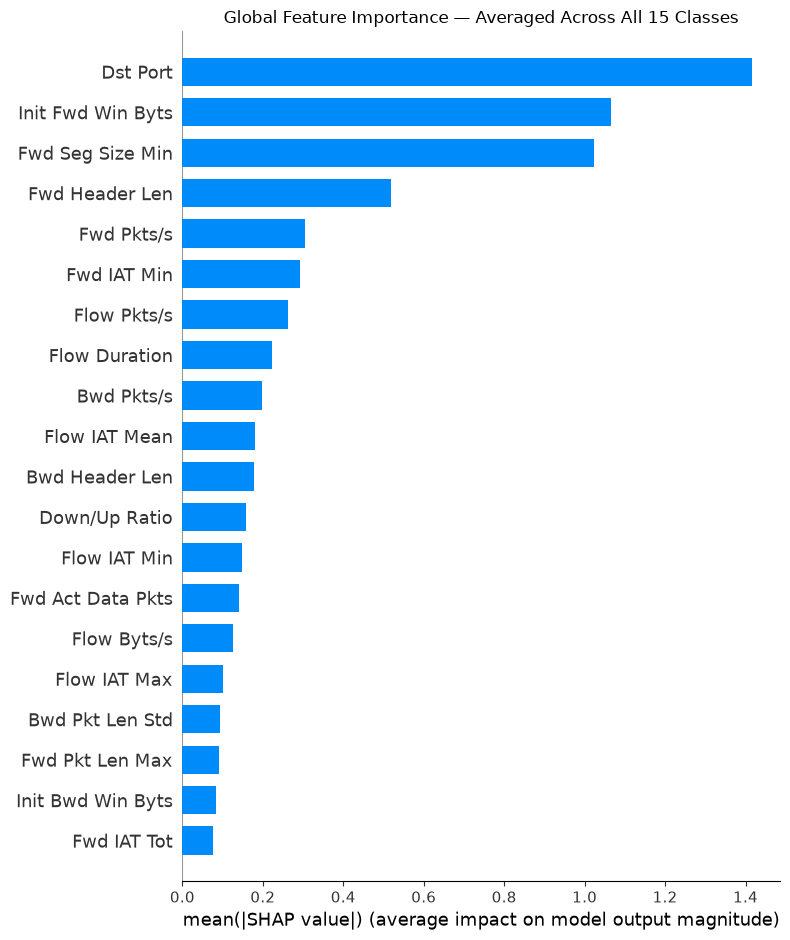


Saved to: ..\outputs\shap_summary_global.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# shap_values shape is (samples, features, classes)
# We average the absolute SHAP value across all classes to get 
# an overall "how important is this feature, regardless of which class" view
mean_abs_shap = np.abs(shap_values).mean(axis=2)  # → shape (1000, 78)

print(f"Aggregated shape for plotting: {mean_abs_shap.shape}")

shap.summary_plot(
    mean_abs_shap, 
    X_shap_sample, 
    plot_type="bar", 
    max_display=20,
    show=False
)
plt.title("Global Feature Importance — Averaged Across All 15 Classes")
plt.tight_layout()

OUTPUT_DIR = Path("../outputs/")
OUTPUT_DIR.mkdir(exist_ok=True)
plt.savefig(OUTPUT_DIR / "shap_summary_global.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {OUTPUT_DIR / 'shap_summary_global.png'}")

In [16]:
def explain_single_prediction(row_index, top_n=5):
    """
    Explain one specific prediction — this is the function pattern
    your dashboard will call for each flagged security event.
    """
    row = X_test_scaled.iloc[[row_index]]
    predicted_class = model.predict(row)[0]
    predicted_label = le.inverse_transform([predicted_class])[0]
    
    # Get SHAP values for this one row, for its predicted class specifically
    row_shap = explainer.shap_values(row)
    class_shap_values = row_shap[0, :, predicted_class]
    
    feature_impact = pd.Series(class_shap_values, index=X_test_scaled.columns)
    top_features = feature_impact.abs().sort_values(ascending=False).head(top_n)
    
    print(f"Predicted class: {predicted_label}")
    print(f"\nTop {top_n} contributing features:")
    for feat in top_features.index:
        direction = "pushes toward" if feature_impact[feat] > 0 else "pushes away from"
        print(f"  {feat}: {feature_impact[feat]:+.4f} ({direction} '{predicted_label}')")

# Test it on one example
explain_single_prediction(row_index=0)

Predicted class: Bot

Top 5 contributing features:
  Dst Port: +10.1063 (pushes toward 'Bot')
  RST Flag Cnt: +0.6912 (pushes toward 'Bot')
  Fwd IAT Mean: +0.6526 (pushes toward 'Bot')
  Flow Byts/s: +0.6226 (pushes toward 'Bot')
  Fwd IAT Max: +0.5921 (pushes toward 'Bot')


In [17]:
# MITRE ATT&CK mapping — corrected per our earlier technical audit
MITRE_MAP = {
    'Benign':                    {'technique_id': None,        'tactic': None},
    'Bot':                       {'technique_id': 'T1071',     'tactic': 'Command and Control'},
    'Brute Force -Web':          {'technique_id': 'T1110',     'tactic': 'Credential Access'},
    'Brute Force -XSS':          {'technique_id': 'T1059.007', 'tactic': 'Execution'},
    'DDOS attack-HOIC':          {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DDOS attack-LOIC-UDP':      {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DDoS attacks-LOIC-HTTP':    {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DoS attacks-GoldenEye':     {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-Hulk':          {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-SlowHTTPTest':  {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-Slowloris':     {'technique_id': 'T1499',     'tactic': 'Impact'},
    'FTP-BruteForce':            {'technique_id': 'T1110',     'tactic': 'Credential Access'},
    'Infilteration':             {'technique_id': 'T1036',     'tactic': 'Defense Evasion'},
    'SQL Injection':             {'technique_id': 'T1190',     'tactic': 'Initial Access'},
    'SSH-Bruteforce':            {'technique_id': 'T1110',     'tactic': 'Credential Access'},
}

# Attach this mapping to a results dataframe for review
mitre_df = pd.DataFrame(MITRE_MAP).T
mitre_df.index.name = 'Attack Category'
print(mitre_df)

                         technique_id               tactic
Attack Category                                           
Benign                           None                 None
Bot                             T1071  Command and Control
Brute Force -Web                T1110    Credential Access
Brute Force -XSS            T1059.007            Execution
DDOS attack-HOIC                T1498               Impact
DDOS attack-LOIC-UDP            T1498               Impact
DDoS attacks-LOIC-HTTP          T1498               Impact
DoS attacks-GoldenEye           T1499               Impact
DoS attacks-Hulk                T1499               Impact
DoS attacks-SlowHTTPTest        T1499               Impact
DoS attacks-Slowloris           T1499               Impact
FTP-BruteForce                  T1110    Credential Access
Infilteration                   T1036      Defense Evasion
SQL Injection                   T1190       Initial Access
SSH-Bruteforce                  T1110    Credential Acce

In [14]:
from datetime import datetime, timezone
import json

MITRE_MAP = {
    'Benign':                    {'technique_id': None,        'tactic': None},
    'Bot':                       {'technique_id': 'T1071',     'tactic': 'Command and Control'},
    'Brute Force -Web':          {'technique_id': 'T1110',     'tactic': 'Credential Access'},
    'Brute Force -XSS':          {'technique_id': 'T1059.007', 'tactic': 'Execution'},
    'DDOS attack-HOIC':          {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DDOS attack-LOIC-UDP':      {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DDoS attacks-LOIC-HTTP':    {'technique_id': 'T1498',     'tactic': 'Impact'},
    'DoS attacks-GoldenEye':     {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-Hulk':          {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-SlowHTTPTest':  {'technique_id': 'T1499',     'tactic': 'Impact'},
    'DoS attacks-Slowloris':     {'technique_id': 'T1499',     'tactic': 'Impact'},
    'FTP-BruteForce':            {'technique_id': 'T1110',     'tactic': 'Credential Access'},
    'Infilteration':             {'technique_id': 'T1036',     'tactic': 'Defense Evasion'},
    'SQL Injection':             {'technique_id': 'T1190',     'tactic': 'Initial Access'},
    'SSH-Bruteforce':            {'technique_id': 'T1110',     'tactic': 'Credential Access'},
}

def build_security_event(row_index, top_n_features=5):
    row = X_test_scaled.iloc[[row_index]]
    predicted_class = model.predict(row)[0]
    predicted_proba = model.predict_proba(row)[0]
    predicted_label = le.inverse_transform([predicted_class])[0]
    confidence = float(predicted_proba[predicted_class])

    mitre_info = MITRE_MAP.get(predicted_label, {'technique_id': None, 'tactic': None})

    row_shap = explainer.shap_values(row)
    class_shap_values = row_shap[0, :, predicted_class]
    feature_impact = pd.Series(class_shap_values, index=X_test_scaled.columns)
    top_features = feature_impact.abs().sort_values(ascending=False).head(top_n_features)

    shap_explanation = [
        {
            "feature": feat,
            "shap_value": round(float(feature_impact[feat]), 4),
            "direction": "increases_confidence" if feature_impact[feat] > 0 else "decreases_confidence"
        }
        for feat in top_features.index
    ]

    event = {
        "@timestamp": datetime.now(timezone.utc).isoformat(),
        "predicted_label": predicted_label,
        "confidence_score": round(confidence, 4),
        "is_attack": predicted_label != 'Benign',
        "mitre_technique_id": mitre_info['technique_id'],
        "mitre_tactic": mitre_info['tactic'],
        "shap_top_features": shap_explanation,
        "dataset_source": "CSE-CIC-IDS2018"
    }
    return event

test_event = build_security_event(row_index=0)
print(json.dumps(test_event, indent=2))

{
  "@timestamp": "2026-09-23T00:27:41.117662+00:00",
  "predicted_label": "Bot",
  "confidence_score": 1.0,
  "is_attack": true,
  "mitre_technique_id": "T1071",
  "mitre_tactic": "Command and Control",
  "shap_top_features": [
    {
      "feature": "Dst Port",
      "shap_value": 10.1063,
      "direction": "increases_confidence"
    },
    {
      "feature": "RST Flag Cnt",
      "shap_value": 0.6912,
      "direction": "increases_confidence"
    },
    {
      "feature": "Fwd IAT Mean",
      "shap_value": 0.6526,
      "direction": "increases_confidence"
    },
    {
      "feature": "Flow Byts/s",
      "shap_value": 0.6226,
      "direction": "increases_confidence"
    },
    {
      "feature": "Fwd IAT Max",
      "shap_value": 0.5921,
      "direction": "increases_confidence"
    }
  ],
  "dataset_source": "CSE-CIC-IDS2018"
}


In [15]:
from datetime import datetime, timezone

def build_security_event(row_index, top_n_features=5):
    """
    Builds one complete security event record combining:
    - XGBoost prediction + confidence
    - MITRE ATT&CK mapping
    - SHAP explanation (top contributing features)
    
    This is the exact structure that will be pushed to Elasticsearch.
    """
    row = X_test_scaled.iloc[[row_index]]
    
    # Prediction
    predicted_class = model.predict(row)[0]
    predicted_proba = model.predict_proba(row)[0]
    predicted_label = le.inverse_transform([predicted_class])[0]
    confidence = float(predicted_proba[predicted_class])
    
    # MITRE mapping
    mitre_info = MITRE_MAP.get(predicted_label, {'technique_id': None, 'tactic': None})
    
    # SHAP explanation
    row_shap = explainer.shap_values(row)
    class_shap_values = row_shap[0, :, predicted_class]
    feature_impact = pd.Series(class_shap_values, index=X_test_scaled.columns)
    top_features = feature_impact.abs().sort_values(ascending=False).head(top_n_features)
    
    shap_explanation = [
        {
            "feature": feat,
            "shap_value": round(float(feature_impact[feat]), 4),
            "direction": "increases_confidence" if feature_impact[feat] > 0 else "decreases_confidence"
        }
        for feat in top_features.index
    ]
    
    # Build the complete event
    event = {
        "@timestamp": datetime.now(timezone.utc).isoformat(),
        "predicted_label": predicted_label,
        "confidence_score": round(confidence, 4),
        "is_attack": predicted_label != 'Benign',
        "mitre_technique_id": mitre_info['technique_id'],
        "mitre_tactic": mitre_info['tactic'],
        "shap_top_features": shap_explanation,
        "dataset_source": "CSE-CIC-IDS2018"
    }
    
    return event

# Test it
import json
test_event = build_security_event(row_index=0)
print(json.dumps(test_event, indent=2))

{
  "@timestamp": "2026-09-23T00:28:00.099290+00:00",
  "predicted_label": "Bot",
  "confidence_score": 1.0,
  "is_attack": true,
  "mitre_technique_id": "T1071",
  "mitre_tactic": "Command and Control",
  "shap_top_features": [
    {
      "feature": "Dst Port",
      "shap_value": 10.1063,
      "direction": "increases_confidence"
    },
    {
      "feature": "RST Flag Cnt",
      "shap_value": 0.6912,
      "direction": "increases_confidence"
    },
    {
      "feature": "Fwd IAT Mean",
      "shap_value": 0.6526,
      "direction": "increases_confidence"
    },
    {
      "feature": "Flow Byts/s",
      "shap_value": 0.6226,
      "direction": "increases_confidence"
    },
    {
      "feature": "Fwd IAT Max",
      "shap_value": 0.5921,
      "direction": "increases_confidence"
    }
  ],
  "dataset_source": "CSE-CIC-IDS2018"
}


In [2]:
from elasticsearch import Elasticsearch, helpers

es = Elasticsearch("http://localhost:9200")

# Confirm connection first
print(es.info()['version']['number'])

8.13.0


In [9]:
import pandas as pd
import numpy as np
import joblib
import shap
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from elasticsearch import Elasticsearch, helpers

CLEAN_DIR = Path("../data/cic2018_clean/")
MODELS_DIR = Path("../models/")

# Reload the already-corrected, already-verified artefacts from disk
model = joblib.load(MODELS_DIR / "xgb_model.pkl")
scaler = joblib.load(MODELS_DIR / "scaler.pkl")
le = joblib.load(MODELS_DIR / "label_encoder.pkl")

# Rebuild the test split exactly as before (same seed, same stratification)
df = pd.read_parquet(CLEAN_DIR / "cic2018_final_sampled.parquet")
df['label_encoded'] = le.transform(df['Label'])
X = df.drop(columns=['Label', 'label_encoded'])
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Rebuild the SHAP explainer from the loaded model
explainer = shap.TreeExplainer(model)

# Reconnect to Elasticsearch
es = Elasticsearch("http://localhost:9200")
print("Elasticsearch:", es.info()['version']['number'])
print("model:", type(model))
print("X_test_scaled shape:", X_test_scaled.shape)

Elasticsearch: 8.13.0
model: <class 'xgboost.sklearn.XGBClassifier'>
X_test_scaled shape: (208219, 78)


In [10]:
# Confirm everything we need is still loaded after the kernel restart
print("model:", type(model))
print("X_test_scaled shape:", X_test_scaled.shape)
print("le classes:", len(le.classes_))
print("explainer:", type(explainer))

model: <class 'xgboost.sklearn.XGBClassifier'>
X_test_scaled shape: (208219, 78)
le classes: 15
explainer: <class 'shap.explainers._tree.TreeExplainer'>


In [25]:
# Step 1 — delete the index entirely, wiping today's 6,000 documents
es.indices.delete(index="ai-secopt-threats-2026.09.23")

ObjectApiResponse({'acknowledged': True})

In [26]:
def push_events_batch(n_events=500):
    """
    Generates n_events security event records from random test set rows
    and bulk-pushes them into Elasticsearch.
    """
    sample_indices = np.random.choice(len(X_test_scaled), size=n_events, replace=False)
    
    index_name = f"ai-secopt-threats-{datetime.now().strftime('%Y.%m.%d')}"
    
    actions = []
    for idx in sample_indices:
        event = build_security_event(row_index=idx)
        actions.append({
            "_index": index_name,
            "_source": event
        })
    
    success, errors = helpers.bulk(es, actions, raise_on_error=False)
    print(f"Successfully indexed: {success}")
    print(f"Errors: {len(errors) if errors else 0}")
    
    return index_name

index_name = push_events_batch(n_events=500)
print(f"\nPushed to index: {index_name}")

Successfully indexed: 500
Errors: 0

Pushed to index: ai-secopt-threats-2026.09.23


In [19]:
# Confirm the index exists and check document count
result = es.count(index=index_name)
print(f"Document count in {index_name}: {result['count']}")

# Pull back one real document to confirm structure looks right
sample = es.search(index=index_name, size=1)
print("\nSample document from Elasticsearch:")
print(json.dumps(sample['hits']['hits'][0]['_source'], indent=2))

Document count in ai-secopt-threats-2026.09.23: 5500

Sample document from Elasticsearch:
{
  "@timestamp": "2026-09-23T00:28:12.641932+00:00",
  "predicted_label": "Benign",
  "confidence_score": 0.9989,
  "is_attack": false,
  "mitre_technique_id": null,
  "mitre_tactic": null,
  "shap_top_features": [
    {
      "feature": "Flow IAT Min",
      "shap_value": 1.1221,
      "direction": "increases_confidence"
    },
    {
      "feature": "Flow Pkts/s",
      "shap_value": 0.4715,
      "direction": "increases_confidence"
    },
    {
      "feature": "Init Fwd Win Byts",
      "shap_value": 0.4594,
      "direction": "increases_confidence"
    },
    {
      "feature": "Flow Duration",
      "shap_value": 0.4395,
      "direction": "increases_confidence"
    },
    {
      "feature": "Flow IAT Mean",
      "shap_value": 0.437,
      "direction": "increases_confidence"
    }
  ],
  "dataset_source": "CSE-CIC-IDS2018"
}


In [27]:
def push_events_batch_optimized(n_events=5000, batch_size=500):
    """
    Optimized version — calculates SHAP values in batches rather than
    one row at a time, which is significantly faster for larger volumes.
    """
    index_name = f"ai-secopt-threats-{datetime.now().strftime('%Y.%m.%d')}"
    sample_indices = np.random.choice(len(X_test_scaled), size=n_events, replace=False)
    
    total_success = 0
    total_errors = 0
    
    for batch_start in range(0, n_events, batch_size):
        batch_indices = sample_indices[batch_start:batch_start + batch_size]
        rows = X_test_scaled.iloc[batch_indices]
        
        # Predict for the whole batch at once
        predicted_classes = model.predict(rows)
        predicted_probas = model.predict_proba(rows)
        
        # SHAP for the whole batch at once — this is the key speedup
        batch_shap = explainer.shap_values(rows)
        
        actions = []
        for i, idx in enumerate(batch_indices):
            pred_class = predicted_classes[i]
            pred_label = le.inverse_transform([pred_class])[0]
            confidence = float(predicted_probas[i][pred_class])
            mitre_info = MITRE_MAP.get(pred_label, {'technique_id': None, 'tactic': None})
            
            class_shap_values = batch_shap[i, :, pred_class]
            feature_impact = pd.Series(class_shap_values, index=X_test_scaled.columns)
            top_features = feature_impact.abs().sort_values(ascending=False).head(5)
            
            shap_explanation = [
                {
                    "feature": feat,
                    "shap_value": round(float(feature_impact[feat]), 4),
                    "direction": "increases_confidence" if feature_impact[feat] > 0 else "decreases_confidence"
                }
                for feat in top_features.index
            ]
            
            event = {
                "@timestamp": datetime.now(timezone.utc).isoformat(),
                "predicted_label": pred_label,
                "confidence_score": round(confidence, 4),
                "is_attack": pred_label != 'Benign',
                "mitre_technique_id": mitre_info['technique_id'],
                "mitre_tactic": mitre_info['tactic'],
                "shap_top_features": shap_explanation,
                "dataset_source": "CSE-CIC-IDS2018"
            }
            actions.append({"_index": index_name, "_source": event})
        
        success, errors = helpers.bulk(es, actions, raise_on_error=False)
        total_success += success
        total_errors += len(errors) if errors else 0
        print(f"  Batch {batch_start}-{batch_start+len(batch_indices)}: {success} indexed")
    
    print(f"\nTotal indexed: {total_success} | Total errors: {total_errors}")
    return index_name

index_name = push_events_batch_optimized(n_events=5000, batch_size=500)

  Batch 0-500: 500 indexed
  Batch 500-1000: 500 indexed
  Batch 1000-1500: 500 indexed
  Batch 1500-2000: 500 indexed
  Batch 2000-2500: 500 indexed
  Batch 2500-3000: 500 indexed
  Batch 3000-3500: 500 indexed
  Batch 3500-4000: 500 indexed
  Batch 4000-4500: 500 indexed
  Batch 4500-5000: 500 indexed

Total indexed: 5000 | Total errors: 0


In [28]:
# Verify Final Count
result = es.count(index="ai-secopt-threats-2026.09.23")
print(f"Documents in today's index: {result['count']}")

Documents in today's index: 5500


In [29]:
# Confirm Metricbeat is running and delivering data to Elasticsearch up to date
latest = es.search(index="*metricbeat*", body={
    "size": 1,  # we only want the single newest document, not a list
    "query": {"exists": {"field": "system.cpu.total.pct"}},
    "sort": [{"@timestamp": {"order": "desc"}}],
    "_source": ["@timestamp", "system.cpu.total.pct"]
})
doc = latest['hits']['hits'][0]['_source']

# Elasticsearch always nests the actual document under hits -> hits -> [0] -> _source
print(f"Most recent reading: {doc['@timestamp']}")
print(f"CPU value: {doc['system']['cpu']['total']['pct']}")

Most recent reading: 2026-09-23T00:58:32.174Z
CPU value: 2.5427


In [30]:
mb_count = es.count(index="metricbeat-*")
print(f"Total Metricbeat documents collected so far: {mb_count['count']:,}")

# Check the actual date range of collected data
mb_sample = es.search(
    index="metricbeat-*", 
    body={"sort": [{"@timestamp": {"order": "asc"}}], "size": 1}
)
earliest = mb_sample['hits']['hits'][0]['_source']['@timestamp']

mb_sample_latest = es.search(
    index="metricbeat-*", 
    body={"sort": [{"@timestamp": {"order": "desc"}}], "size": 1}
)
latest = mb_sample_latest['hits']['hits'][0]['_source']['@timestamp']

print(f"Earliest reading: {earliest}")
print(f"Latest reading: {latest}")

Total Metricbeat documents collected so far: 1,024,254
Earliest reading: 2026-08-18T02:19:12.440Z
Latest reading: 2026-09-23T01:02:12.174Z
